# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


# UCI Part 5: UCI Optimisation

This notebook runs Ising-model-based optimisation for UCI improvement priorities.

Data source used in this notebook:
- `data/data_uci_modelling_with_preds_uci.gpkg` (UCI modelling data with activity predictions)

Outputs saved by this notebook:



## Read UCI data

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read UCI modelling data with predictions
uci_gdf = gpd.read_file("data/data_uci_modelling_with_preds_uci.gpkg")

# check the columns
print(uci_gdf.columns)

Index(['id', 'longitude', 'latitude', 'SP_1-E_comfort',
       'SP_2-E_sunshine_intensity', 'SP_3-E_temp_inference',
       'SP_4-E_humidity_inference', 'SP_5-E_wind_inference',
       'SP_6-E_greenery_rate', 'SP_7-E_shading_area', 'SP_8-E_heat_source',
       'SP_9-E_traffic_flow', 'SP_1-D_imageability', 'SP_2-D_enclosure',
       'SP_3-D_human_scale', 'SP_4-D_complexity', 'FC_1-R_eating_rating',
       'FC_1-D_eating_density', 'FC_2-R_retail_rating',
       'FC_2-D_retail_density', 'FC_3-R_life_rating', 'FC_3-D_life_density',
       'FC_4-R_recreation_rating', 'FC_4-D_recreation_density',
       'FC_5-R_health_rating', 'FC_5-D_health_density',
       'FC_6-R_community_rating', 'FC_6-D_community_density',
       'FC_7-R_trans_rating', 'FC_7-D_trans_density', 'FC_1-H_HDB_density',
       'FC_1-G_review_polarity', 'FC_2-G_review_subjectivity',
       'AC_1-L_closeness400', 'AC_2-L_closeness800', 'AC_1-G_closeness2000',
       'AC_2-G_closeness6000', 'AC_1-T_subway_accessibility',
      

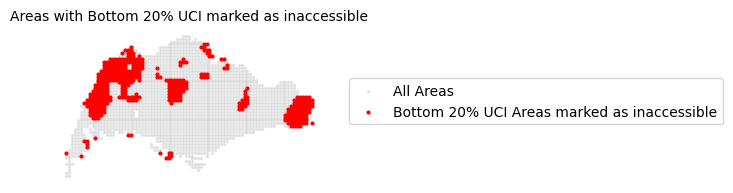

In [3]:
# This part is to find the areas with low UCI score and mark them as inaccessible.
# The threshold is set as the 20% quantile of the UCI total score.
# The purpose is to exclude the areas with low UCI score from the optimization process.

# Get all UCI prediction columns (hybrid GWR predictions per activity)
uci_cols = ['UCI_1_eating_and_drinking', 'UCI_2_nature_exploration',
       'UCI_3_community_gathering', 'UCI_4_walking_and_exercising',
       'UCI_5_urban_sightseeing']
uci_cols = [c for c in uci_cols if c in uci_gdf.columns]
if not uci_cols:
    raise ValueError("No UCI prediction columns found in uci_gdf. Expected columns like eating_hybrid_gwr_pred, ...")

# Calculate total UCI score for each area
uci_gdf['uci_total'] = uci_gdf[uci_cols].sum(axis=1)

# Find areas in bottom 20% of UCI total scores
threshold = uci_gdf['uci_total'].quantile(0.2)

# Create is_inaccessible column
uci_gdf['is_inaccessible'] = uci_gdf['uci_total'] <= threshold

# Get low accessibility areas
low_uci = uci_gdf[uci_gdf['is_inaccessible']]

# Visualize using the GeoDataFrame's own plot method
fig, ax = plt.subplots(figsize=(3, 2))
uci_gdf.plot(ax=ax, color='lightgrey', markersize=2, alpha=0.5, label='All Areas')
low_uci.plot(ax=ax, color='red', markersize=4, label='Bottom 20% UCI Areas marked as inaccessible')
# Use fig.legend to display the legend outside the plot to avoid overlapping with the plot
fig.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.title('Areas with Bottom 20% UCI marked as inaccessible', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()


## Calculate policy-driven UCI (pUCI)

In [4]:
puci_1_weights = [0.2, 0.2, 0.2, 0.2, 0.2]
puci_2_weights = [0.0, 0.7, 0.1, 0.2, 0.0]
puci_3_weights = [0.0, 0.1, 0.7, 0.2, 0.0]
puci_4_weights = [0.0, 0.2, 0.0, 0.7, 0.1]
puci_5_weights = [0.1, 0.0, 0.0, 0.2, 0.7]

puci_cols = ['pUCI_1_balanced_development',
       'pUCI_2_eco_livable', 'pUCI_3_community_cohension',
       'pUCI_4_active_walkability', 'pUCI_5_tourism_strategy']

# UCI activity columns in same order as weight dimensions (eating, nature, community, walking, sightseeing)
uci_cols_for_puci = ['UCI_1_eating_and_drinking', 'UCI_2_nature_exploration',
                     'UCI_3_community_gathering', 'UCI_4_walking_and_exercising',
                     'UCI_5_urban_sightseeing']
uci_cols_for_puci = [c for c in uci_cols_for_puci if c in uci_gdf.columns]
if len(uci_cols_for_puci) != 5:
    raise ValueError(f"Expected 5 UCI columns in uci_gdf, found {len(uci_cols_for_puci)}: {uci_cols_for_puci}")

# Apply each pUCI's weights to uci_cols in order and save score into puci_cols
puci_weights_list = [puci_1_weights, puci_2_weights, puci_3_weights, puci_4_weights, puci_5_weights]
for i, puci_col in enumerate(puci_cols):
    # pUCI score = weighted sum of the 5 UCI activity scores
    uci_gdf[puci_col] = sum(
        puci_weights_list[i][j] * uci_gdf[uci_cols_for_puci[j]]
        for j in range(5)
    )

print("pUCI scores computed and saved to uci_gdf columns:", puci_cols)

# Output descriptive statistics for each pUCI
for puci_col in puci_cols:
    desc = uci_gdf[puci_col].describe()
    print(f"\nDescriptive statistics for {puci_col}:")
    print(desc)
    print(f"Min: {desc['min']}, Max: {desc['max']}, Mean: {desc['mean']}, Std: {desc['std']}")

pUCI scores computed and saved to uci_gdf columns: ['pUCI_1_balanced_development', 'pUCI_2_eco_livable', 'pUCI_3_community_cohension', 'pUCI_4_active_walkability', 'pUCI_5_tourism_strategy']

Descriptive statistics for pUCI_1_balanced_development:
count    2096.000000
mean        0.458532
std         0.237441
min         0.004430
25%         0.269145
50%         0.493756
75%         0.666605
max         0.925610
Name: pUCI_1_balanced_development, dtype: float64
Min: 0.004429970471995279, Max: 0.9256098515879576, Mean: 0.4585324207961704, Std: 0.23744105816690877

Descriptive statistics for pUCI_2_eco_livable:
count    2096.000000
mean        0.360111
std         0.195910
min         0.006044
25%         0.211545
50%         0.372773
75%         0.481428
max         0.947480
Name: pUCI_2_eco_livable, dtype: float64
Min: 0.006044329016404013, Max: 0.947479952894314, Mean: 0.3601114688613491, Std: 0.19590992771781449

Descriptive statistics for pUCI_3_community_cohension:
count    2096.00

## UCI optimisation with ising model

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Qiskit related libraries
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

np.random.seed(42)

import os

# Optimisation result output directory (change this to your desired path)
OPTIMISATION_RESULT_DIR = "data/optimisation_result_user"
os.makedirs(OPTIMISATION_RESULT_DIR, exist_ok=True)

In [6]:
def run_ising_optimization(uci_gdf, puci_col, selected_feature,
                          pop_col='CD_1-P_population', building_density_col='CD_1-B_building_density',
                          w1=3, w2=3, w3=1, w4=1, policy_threshold=0.9,
                          ising_initial_temperature=3.0, ising_final_temperature=0.05, 
                          ising_cooling_rate=0.985, ising_temperature=2.0, 
                          ising_external_field=1.0, ising_global_penalty_weight=0.5,
                          ising_max_steps=200, ising_record_interval=1,
                          target_activation_ratio=0.2, 
                          save_steps=[1, 5, 10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200],
                          save_results=True, show_plots=True):
    """
    Run Ising model optimization for a specific pUCI and feature
    
    Parameters:
    - uci_gdf: GeoDataFrame with spatial data
    - puci_col: pUCI column name (e.g., 'pUCI_1_balanced_development', etc.)
    - selected_feature: feature to optimize (e.g., 'SP_1-D_imageability')
    - pop_col: population column name
    - building_density_col: building density column name
    - w1-w4: weight parameters
    - policy_threshold: policy penalty threshold
    - ising_*: Ising model parameters
    - target_activation_ratio: target activation ratio (default 20%)
    - save_steps: list of steps to save snapshots
    - save_results: whether to save results to files
    - show_plots: whether to show visualization plots
    
    Returns:
    - optimized_gdf: GeoDataFrame with optimization results
    - ising_optimizer: IsingOptimizer object with optimization history
    """
    
    print(f"\nStarting processing {puci_col} - single feature optimization: {selected_feature}...")
    
    # Create a copy of the input GeoDataFrame to avoid modifying the original
    gdf = uci_gdf.copy()
    
    # Check dataset features
    print("Checking dataset features...")
    if selected_feature not in gdf.columns:
        print(f"Error: Feature {selected_feature} is not in the dataset.")
        raise ValueError(f"Feature {selected_feature} does not exist")
    
    if puci_col not in gdf.columns:
        print(f"Error: pUCI column {puci_col} is not in the dataset.")
        raise ValueError(f"pUCI column {puci_col} does not exist")

    # Calculate feature sensitivity
    corr_value = gdf[selected_feature].corr(gdf[puci_col])
    if pd.isna(corr_value):
        corr_value = 0
    sensitivity = abs(corr_value)
    
    # Output feature name and sensitivity
    print(f"\nFeature sensitivity analysis results:")
    print(f"{selected_feature}: {sensitivity:.4f}")
    
    # Visualize pUCI distribution
    if show_plots:
        plt.figure(figsize=(10, 5))
        plt.scatter(gdf['longitude'], gdf['latitude'],
                    c=gdf[puci_col], cmap='viridis',
                    s=10, alpha=0.7)
        plt.colorbar(label=f'{puci_col} Score')
        plt.title(f'{puci_col} Distribution')
        plt.show()
    
    # Normalize population
    pop_min = gdf[pop_col].min()
    pop_max = gdf[pop_col].max()
    pop_norm_series = (gdf[pop_col] - pop_min) / (pop_max - pop_min)
    
    # Normalize building density
    building_density_min = gdf[building_density_col].min()
    building_density_max = gdf[building_density_col].max()
    building_density_norm_series = (gdf[building_density_col] - building_density_min) / (building_density_max - building_density_min)
    
    # Visualize normalized distributions
    if show_plots:
        plt.figure(figsize=(10, 5))
        plt.scatter(gdf['longitude'], gdf['latitude'], 
                    c=pop_norm_series, cmap='plasma', 
                    s=10, alpha=0.7)
        plt.colorbar(label='Normalized Population')
        plt.title('Normalized Population Distribution')
        plt.show()
        
        plt.figure(figsize=(10, 5))
        plt.scatter(gdf['longitude'], gdf['latitude'], 
                    c=building_density_norm_series, cmap='viridis', 
                    s=10, alpha=0.7)
        plt.colorbar(label='Normalized Building Density')
        plt.title('Normalized Building Density Distribution')
        plt.show()
    
    print(f"\nStarting optimization score calculation (including population, accessibility, building density, {puci_col} score)...")
    
    # Filter out inaccessible points, only calculate for accessible points
    if 'is_inaccessible' in gdf.columns:
        accessible_mask = ~gdf['is_inaccessible']
        accessible_data = gdf[accessible_mask]
    else:
        accessible_data = gdf
    
    # Calculate gap_normalized_series (only for accessible points)
    current_values = accessible_data[selected_feature]
    global_mean = current_values.mean()
    
    # Calculate gap, if current value is higher than mean then gap is 0
    gaps = np.maximum(0, global_mean - current_values)
    
    # Normalize gap
    if gaps.max() > gaps.min():
        gap_normalized_series = (gaps - gaps.min()) / (gaps.max() - gaps.min())
    else:
        gap_normalized_series = pd.Series(0, index=accessible_data.index)
    
    # Calculate pUCI penalty term
    policy_penalty = np.clip((accessible_data[puci_col] - policy_threshold) / (1 - policy_threshold), 0, 1)
    
    # Calculate score for each accessible point
    accessible_data_copy = accessible_data.copy()
    accessible_data_copy[f"{selected_feature}_score"] = w1 * (1 - policy_penalty) \
                                           + w2 * sensitivity * gap_normalized_series \
                                           + w3 * accessible_data[pop_col].apply(lambda x: (x - pop_min) / (pop_max - pop_min)) \
                                           + w4 * accessible_data[building_density_col].apply(lambda x: (x - building_density_min) / (building_density_max - building_density_min))
    
    # Update score information to original dataframe
    gdf[f"{selected_feature}_score"] = 0  # Initialize to 0 first
    gdf.loc[accessible_data.index, f"{selected_feature}_score"] = accessible_data_copy[f"{selected_feature}_score"]
    
    print(f"Feature {selected_feature}: Calculated scores for {len(accessible_data)} accessible points")
    print(f"Average score: {accessible_data_copy[f'{selected_feature}_score'].mean():.4f}")
    
    print(f"\nFeature score statistics:")
    print(f"Average score: {gdf[f'{selected_feature}_score'].mean():.4f}")
    print(f"Median score: {gdf[f'{selected_feature}_score'].median():.4f}")
    print(f"Maximum score: {gdf[f'{selected_feature}_score'].max():.4f}")
    print(f"Minimum score: {gdf[f'{selected_feature}_score'].min():.4f}")
    print(f"Standard deviation: {gdf[f'{selected_feature}_score'].std():.4f}")
    
    # Visualize score distribution
    if show_plots:
        plt.figure(figsize=(6, 3))
        scatter = plt.scatter(gdf['longitude'], 
                             gdf['latitude'], 
                             c=gdf[f'{selected_feature}_score'], 
                             cmap='viridis', s=15, alpha=0.7)
        plt.colorbar(scatter, label='Score')
        plt.title(f'{puci_col} - {selected_feature} Score Distribution')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.tight_layout()
        plt.show()

        # Score histogram
        plt.figure(figsize=(6, 3))
        plt.hist(gdf[f'{selected_feature}_score'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.title(f'{puci_col} - {selected_feature} Score Distribution')
        plt.xlabel('Score')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # ==================== Ising Model Optimization with Simulated Annealing ====================
    print("\nStarting four-neighbor optimization based on Ising model with simulated annealing...")
    
    class IsingOptimizer:
        def __init__(self, gdf, feature_col, score_col, initial_temp=10.0, final_temp=0.01, 
                     cooling_rate=0.995, temperature=1.0, external_field=0.0, global_penalty_weight=0.5, target_ratio=0.2):
            """
            Initialize Ising Model for spatial optimization with simulated annealing
            
            Parameters:
            - gdf: GeoDataFrame with spatial data
            - feature_col: feature column name for optimization
            - score_col: score column name
            - initial_temp: initial temperature for annealing
            - final_temp: final temperature for annealing
            - cooling_rate: cooling rate (temperature multiplier each step)
            - temperature: system temperature (controls randomness)
            - external_field: external field strength
            - global_penalty_weight: weight for global penalty term to maintain target activation
            - target_ratio: target activation ratio (default 20%)
            """
            self.gdf = gdf.copy()
            self.feature_col = feature_col
            self.score_col = score_col
            self.initial_temp = initial_temp
            self.final_temp = final_temp
            self.cooling_rate = cooling_rate
            self.current_temp = initial_temp
            self.temperature = temperature
            self.external_field = external_field
            self.global_penalty_weight = global_penalty_weight
            self.target_ratio = target_ratio
            self.beta = 1.0 / temperature if temperature > 0 else float('inf')
            
            # Create spatial grid mapping
            self.create_spatial_grid()
            
            # Initialize spin configuration randomly (not based on existing recommendations)
            self.initialize_spins()
            
            # Calculate target activation count
            accessible_mask = ~self.gdf.get('is_inaccessible', pd.Series(False, index=self.gdf.index))
            self.total_accessible = accessible_mask.sum()
            self.target_activation_count = int(self.total_accessible * self.target_ratio)
            
            # Store optimization history
            self.energy_history = []
            self.activation_history = []
            self.temperature_history = []
            self.step_history = []
            self.step = 0
            
            # Store snapshots at specific steps
            self.snapshots = {}
            
            print(f"Target activation count: {self.target_activation_count} (total accessible points: {self.total_accessible})")
            print(f"Initial temperature: {self.initial_temp}, Final temperature: {self.final_temp}, Cooling rate: {self.cooling_rate}")
            
        def create_spatial_grid(self):
            """Create spatial grid mapping for neighbor relationships"""
            # Get unique coordinates and create grid
            unique_lons = sorted(self.gdf['longitude'].unique())
            unique_lats = sorted(self.gdf['latitude'].unique())
            
            # Create coordinate to grid index mapping
            self.lon_to_idx = {lon: i for i, lon in enumerate(unique_lons)}
            self.lat_to_idx = {lat: i for i, lat in enumerate(unique_lats)}
            
            self.grid_height = len(unique_lats)
            self.grid_width = len(unique_lons)
            
            # Create point to grid mapping
            self.point_to_grid = {}
            self.grid_to_point = {}
            
            for idx, row in self.gdf.iterrows():
                grid_i = self.lat_to_idx[row['latitude']]
                grid_j = self.lon_to_idx[row['longitude']]
                self.point_to_grid[idx] = (grid_i, grid_j)
                self.grid_to_point[(grid_i, grid_j)] = idx
                
        def initialize_spins(self):
            """Initialize spin configuration randomly to achieve approximately target activation ratio"""
            self.spins = np.zeros((self.grid_height, self.grid_width))
            
            # Get all valid grid positions (where we have actual data points)
            valid_positions = list(self.grid_to_point.keys())
            
            # Randomly select approximately target ratio of positions to activate
            num_to_activate = int(len(valid_positions) * self.target_ratio)
            activated_positions = np.random.choice(len(valid_positions), size=num_to_activate, replace=False)
            
            for pos_idx in activated_positions:
                grid_i, grid_j = valid_positions[pos_idx]
                self.spins[grid_i, grid_j] = 1
                
            # Set all other valid positions to -1
            for grid_i, grid_j in valid_positions:
                if self.spins[grid_i, grid_j] == 0:
                    self.spins[grid_i, grid_j] = -1
                    
        def get_neighbors(self, i, j):
            """Get four neighbors of grid position (i,j)"""
            neighbors = []
            directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right
            
            for di, dj in directions:
                ni, nj = i + di, j + dj
                if 0 <= ni < self.grid_height and 0 <= nj < self.grid_width:
                    if (ni, nj) in self.grid_to_point:  # Only if there's actual data point
                        neighbors.append((ni, nj))
            return neighbors
            
        def calculate_current_activation_count(self):
            """Calculate current number of activated spins (spin = +1)"""
            count = 0
            for i in range(self.grid_height):
                for j in range(self.grid_width):
                    if (i, j) in self.grid_to_point:
                        if self.spins[i, j] > 0:
                            count += 1
            return count
            
        def calculate_local_energy(self, i, j):
            """Calculate local energy for position (i,j)"""
            if (i, j) not in self.grid_to_point:
                return 0
                
            point_idx = self.grid_to_point[(i, j)]
            current_spin = self.spins[i, j]
            
            # Interaction energy with neighbors (ferromagnetic coupling)
            interaction_energy = 0
            neighbors = self.get_neighbors(i, j)
            for ni, nj in neighbors:
                interaction_energy += -current_spin * self.spins[ni, nj]  # Ferromagnetic coupling
                
            # External field energy (based on optimization score)
            score = self.gdf.loc[point_idx, self.score_col]
            normalized_score = score / self.gdf[self.score_col].max() if self.gdf[self.score_col].max() > 0 else 0
            field_energy = -self.external_field * normalized_score * current_spin
            
            # Global penalty term to maintain target activation
            current_activation = self.calculate_current_activation_count()
            activation_deviation = current_activation - self.target_activation_count
            
            # Penalty increases quadratically with deviation from target
            global_penalty = self.global_penalty_weight * (activation_deviation ** 2) / self.total_accessible
            
            # Apply penalty based on spin direction
            if current_spin > 0:  # If activated
                if current_activation > self.target_activation_count:
                    # Too many activations, penalize activation
                    global_penalty_energy = global_penalty
                else:
                    # Too few activations, reward activation
                    global_penalty_energy = -global_penalty
            else:  # If deactivated
                if current_activation < self.target_activation_count:
                    # Too few activations, penalize deactivation
                    global_penalty_energy = global_penalty
                else:
                    # Too many activations, reward deactivation
                    global_penalty_energy = -global_penalty
            
            return interaction_energy + field_energy + global_penalty_energy
            
        def calculate_total_energy(self):
            """Calculate total system energy"""
            total_energy = 0
            for i in range(self.grid_height):
                for j in range(self.grid_width):
                    if (i, j) in self.grid_to_point:
                        total_energy += self.calculate_local_energy(i, j)
            return total_energy / 2.0  # Avoid double counting interactions
            
        def save_snapshot(self, step):
            """Save current state as snapshot"""
            snapshot_gdf = self.gdf.copy()
            
            # Update recommendations based on current spins
            for idx, row in snapshot_gdf.iterrows():
                if idx in self.point_to_grid:
                    grid_i, grid_j = self.point_to_grid[idx]
                    spin_value = self.spins[grid_i, grid_j]
                    snapshot_gdf.loc[idx, f"{self.feature_col}_recommendation"] = 1 if spin_value > 0 else 0
                else:
                    snapshot_gdf.loc[idx, f"{self.feature_col}_recommendation"] = 0
                    
            self.snapshots[step] = snapshot_gdf
            
        def monte_carlo_step(self):
            """Perform one Monte Carlo step using Metropolis algorithm with simulated annealing"""
            # Get all valid grid positions
            valid_positions = list(self.grid_to_point.keys())
            
            for _ in range(len(valid_positions)):
                # Choose random position
                i, j = valid_positions[np.random.randint(len(valid_positions))]
                
                # Calculate energy change if we flip this spin
                old_energy = self.calculate_local_energy(i, j)
                
                # Flip spin temporarily
                self.spins[i, j] *= -1
                new_energy = self.calculate_local_energy(i, j)
                
                delta_energy = new_energy - old_energy
                
                # Accept or reject the flip using simulated annealing criterion
                if delta_energy <= 0:
                    # Accept the flip - energy decreased
                    pass
                else:
                    # Accept with probability exp(-delta_E/T) using current annealing temperature
                    if self.current_temp > 0 and np.random.random() < np.exp(-delta_energy / self.current_temp):
                        # Accept the flip
                        pass
                    else:
                        # Reject the flip - flip back
                        self.spins[i, j] *= -1
            
            # Cool down the temperature
            self.current_temp = max(self.final_temp, self.current_temp * self.cooling_rate)
            self.step += 1
            
        def optimize(self, max_steps=1000, record_interval=10, save_steps=None):
            """Run optimization for specified number of steps"""
            print(f"Starting Ising model optimization with simulated annealing, maximum steps: {max_steps}")
            
            if save_steps is None:
                save_steps = []
                
            # Record initial state
            initial_energy = self.calculate_total_energy()
            initial_activation = self.calculate_current_activation_count()
            self.energy_history.append(initial_energy)
            self.activation_history.append(initial_activation)
            self.temperature_history.append(self.current_temp)
            self.step_history.append(0)
            
            # Save initial snapshot if step 0 is requested
            if 0 in save_steps:
                self.save_snapshot(0)
            
            for step in tqdm(range(max_steps), desc="Ising Optimization"):
                self.monte_carlo_step()
                
                if step % record_interval == 0:
                    current_energy = self.calculate_total_energy()
                    current_activation = self.calculate_current_activation_count()
                    self.energy_history.append(current_energy)
                    self.activation_history.append(current_activation)
                    self.temperature_history.append(self.current_temp)
                    self.step_history.append(step + 1)
                    
                # Save snapshot if this step is in save_steps
                if (step + 1) in save_steps:
                    self.save_snapshot(step + 1)
                    
            print("Ising model optimization with simulated annealing completed")
            print(f"Final temperature: {self.current_temp:.6f}")
            
        def update_recommendations(self):
            """Update GeoDataFrame with optimized recommendations"""
            for idx, row in self.gdf.iterrows():
                if idx in self.point_to_grid:
                    grid_i, grid_j = self.point_to_grid[idx]
                    # Convert spin (-1/+1) back to recommendation (0/1)
                    spin_value = self.spins[grid_i, grid_j]
                    self.gdf.loc[idx, f"{self.feature_col}_recommendation"] = 1 if spin_value > 0 else 0
                    
        def visualize_optimization(self, record_interval):
            """Visualize optimization results"""
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # Ising optimized recommendations
            ising_rec = self.gdf[self.gdf[f"{self.feature_col}_recommendation"] == 1]
            axes[0, 0].scatter(self.gdf['longitude'], self.gdf['latitude'], 
                              c='lightgrey', s=5, alpha=0.3)
            axes[0, 0].scatter(ising_rec['longitude'], ising_rec['latitude'], 
                              c='red', s=10, alpha=0.7)
            axes[0, 0].set_title('Ising Model Optimization Results')
            
            # Score distribution
            sc1 = axes[0, 1].scatter(self.gdf['longitude'], self.gdf['latitude'], 
                        c=self.gdf[self.score_col], cmap='viridis', 
                        s=10, alpha=0.7)
            axes[0, 1].set_title(f'{self.feature_col} Score Distribution')
            plt.colorbar(sc1, ax=axes[0, 1])
            
            # Temperature evolution
            if len(self.temperature_history) > 1:
                axes[0, 2].plot(self.step_history, self.temperature_history, 'orange', linewidth=2)
                axes[0, 2].set_title('Temperature Evolution')
                axes[0, 2].set_xlabel('Monte Carlo Steps')
                axes[0, 2].set_ylabel('Temperature')
                axes[0, 2].set_yscale('log')
                axes[0, 2].grid(True)
            else:
                axes[0, 2].text(0.5, 0.5, 'No temperature data', ha='center', va='center', transform=axes[0, 2].transAxes)
                axes[0, 2].set_title('Temperature Evolution')
            
            # Energy evolution
            if len(self.energy_history) > 1:
                axes[1, 0].plot(self.step_history, self.energy_history, 'g-', linewidth=2)
                axes[1, 0].set_title('Energy Evolution')
                axes[1, 0].set_xlabel('Monte Carlo Steps')
                axes[1, 0].set_ylabel('System Energy')
                axes[1, 0].grid(True)
            else:
                axes[1, 0].text(0.5, 0.5, 'No energy data', ha='center', va='center', transform=axes[1, 0].transAxes)
                axes[1, 0].set_title('Energy Evolution')
            
            # Activation count evolution
            if len(self.activation_history) > 1:
                axes[1, 1].plot(self.step_history, self.activation_history, 'b-', linewidth=2)
                axes[1, 1].axhline(y=self.target_activation_count, color='r', linestyle='--', 
                                  label=f'Target ({self.target_activation_count})')
                axes[1, 1].set_title('Activation Count Evolution')
                axes[1, 1].set_xlabel('Monte Carlo Steps')
                axes[1, 1].set_ylabel('Number of Activated Points')
                axes[1, 1].legend()
                axes[1, 1].grid(True)
            else:
                axes[1, 1].text(0.5, 0.5, 'No activation data', ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('Activation Count Evolution')
            
            # Acceptance rate over time (approximated from energy changes)
            if len(self.energy_history) > 10:
                # Calculate approximate acceptance rate based on energy changes
                energy_changes = np.diff(self.energy_history)
                window_size = max(10, len(energy_changes) // 20)
                acceptance_rates = []
                for i in range(window_size, len(energy_changes)):
                    window = energy_changes[i-window_size:i]
                    # Count non-zero changes as accepted moves
                    acceptance_rate = np.sum(np.abs(window) > 1e-10) / len(window)
                    acceptance_rates.append(acceptance_rate)
                
                if acceptance_rates:
                    axes[1, 2].plot(self.step_history[window_size+1:len(acceptance_rates)+window_size+1], 
                                   acceptance_rates, 'purple', linewidth=2)
                    axes[1, 2].set_title('Approximate Acceptance Rate')
                    axes[1, 2].set_xlabel('Monte Carlo Steps')
                    axes[1, 2].set_ylabel('Acceptance Rate')
                    axes[1, 2].grid(True)
                else:
                    axes[1, 2].text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=axes[1, 2].transAxes)
                    axes[1, 2].set_title('Approximate Acceptance Rate')
            else:
                axes[1, 2].text(0.5, 0.5, 'No acceptance data', ha='center', va='center', transform=axes[1, 2].transAxes)
                axes[1, 2].set_title('Approximate Acceptance Rate')
            
            plt.tight_layout()
            plt.show()
    
    # Apply Ising model optimization with simulated annealing
    ising_optimizer = IsingOptimizer(
        gdf=gdf,
        feature_col=selected_feature,
        score_col=f"{selected_feature}_score",
        initial_temp=ising_initial_temperature,
        final_temp=ising_final_temperature,
        cooling_rate=ising_cooling_rate,
        temperature=ising_temperature,
        external_field=ising_external_field,
        global_penalty_weight=ising_global_penalty_weight,
        target_ratio=target_activation_ratio
    )
    
    # Run optimization
    ising_optimizer.optimize(max_steps=ising_max_steps, record_interval=ising_record_interval, save_steps=save_steps)
    
    # Update recommendation results
    ising_optimizer.update_recommendations()
    
    # Visualize results
    if show_plots:
        ising_optimizer.visualize_optimization(record_interval=ising_record_interval)
    
    # Update main dataframe
    gdf = ising_optimizer.gdf
    
    # Statistical results
    ising_count = gdf[f"{selected_feature}_recommendation"].sum()
    
    print(f"\nIsing model optimization results:")
    print(f"Recommended points: {ising_count}")
    print(f"Target activation count: {ising_optimizer.target_activation_count}")
    print(f"Activation ratio: {ising_count / ising_optimizer.total_accessible * 100:.1f}%")
    print(f"Final temperature: {ising_optimizer.current_temp:.6f}")
    
    # Calculate spatial clustering (using four-neighbor relationship)
    def calculate_spatial_clustering(gdf, rec_col):
        """Calculate spatial clustering coefficient"""
        clustering_score = 0
        total_pairs = 0
        
        for idx, row in gdf.iterrows():
            if row[rec_col] == 1:  # Only for recommended points
                # Find neighbors within small distance (approximate grid neighbors)
                neighbors = gdf[
                    (abs(gdf['longitude'] - row['longitude']) < 0.01) & 
                    (abs(gdf['latitude'] - row['latitude']) < 0.01) &
                    (gdf.index != idx)
                ]
                
                for _, neighbor in neighbors.iterrows():
                    total_pairs += 1
                    if neighbor[rec_col] == 1:
                        clustering_score += 1
                        
        return clustering_score / total_pairs if total_pairs > 0 else 0
    
    ising_clustering = calculate_spatial_clustering(gdf, f"{selected_feature}_recommendation")
    
    print(f"\nSpatial clustering analysis:")
    print(f"Ising model clustering: {ising_clustering:.4f}")
    
    # ==================== Save Optimization Results for Different Steps ====================
    if save_results:
        print(f"\nStarting to save optimization results for different steps...")
        
        # Save results for each step
        for step in save_steps:
            if step in ising_optimizer.snapshots:
                snapshot_gdf = ising_optimizer.snapshots[step]
                
                # Prepare data to save: only keep id, score, recommendation and geometry columns
                save_columns = ['id', f"{selected_feature}_score", f"{selected_feature}_recommendation", 'geometry']
                
                # Check if id column exists, if not use index
                if 'id' not in snapshot_gdf.columns:
                    snapshot_gdf['id'] = snapshot_gdf.index
                    
                save_gdf = snapshot_gdf[save_columns].copy()
                
                # Save file
                output_name = f'PUCI_ising_optimisation_{puci_col}_{selected_feature}_step_{step}'
                output_path = f'{OPTIMISATION_RESULT_DIR}/{output_name}.gpkg'
                save_gdf.to_file(output_path, driver='GPKG')
                
                print(f"Saved step {step} results to: {output_path}")
                print(f"  - Recommended points: {save_gdf[f'{selected_feature}_recommendation'].sum()}")
        
        # Save energy evolution as CSV
        energy_df = pd.DataFrame({
            'step': ising_optimizer.step_history,
            'energy': ising_optimizer.energy_history,
            'activation_count': ising_optimizer.activation_history,
            'temperature': ising_optimizer.temperature_history
        })
        
        energy_csv_name = f'PUCI_ising_energy_evolution_{puci_col}_{selected_feature}'
        energy_csv_path = f'{OPTIMISATION_RESULT_DIR}/{energy_csv_name}.csv'
        energy_df.to_csv(energy_csv_path, index=False)
        
        print(f"\nSaved energy evolution to: {energy_csv_path}")
        print(f"Energy evolution data contains {len(energy_df)} record points")
        
        # Save final complete results (only keep four columns)
        final_columns = ['id', f"{selected_feature}_score", f"{selected_feature}_recommendation", 'geometry']
        
        # Check if id column exists, if not use index
        if 'id' not in gdf.columns:
            gdf['id'] = gdf.index
        
        final_save_gdf = gdf[['id', f"{selected_feature}_score", f"{selected_feature}_recommendation", 'geometry']].copy()
        
        output_name = f'PUCI_ising_optimisation_{puci_col}_{selected_feature}'
        output_path = f'{OPTIMISATION_RESULT_DIR}/{output_name}.gpkg'
        final_save_gdf.to_file(output_path, driver='GPKG')
        print(f"\nSaved {puci_col} - {selected_feature} Ising model complete optimization results to: {output_path}")
        print(f"Final results contain columns: {list(final_save_gdf.columns)}")
    
    return gdf, ising_optimizer

In [ ]:
# Run optimization for all pUCI columns with all 9 features
# puci_cols defined in "Calculate policy-driven UCI (pUCI)" section above
features = [
    'SP_6-E_greenery_rate',
    'SP_1-D_imageability',
    'SP_7-E_shading_area',
    'SP_3-D_human_scale',
    'FC_3-R_life_rating',
    'FC_3-D_life_density',
    'AC_1-T_subway_accessibility',
    'AC_3-T_bus_accessibility',
    'CD_1-L_leisure_density'
]

print(f"Running optimization for {len(puci_cols)} pUCI columns with {len(features)} features")
print(f"pUCI columns: {puci_cols}")
print(f"Features: {features}")
print(f"Total combinations: {len(puci_cols) * len(features)}")

results = {}
total_combinations = len(puci_cols) * len(features)
current_combination = 0

for puci_col in puci_cols:
    for feature in features:
        current_combination += 1
        print(f"\n{'='*80}")
        print(f"Processing combination {current_combination}/{total_combinations}")
        print(f"pUCI: {puci_col}, Feature: {feature}")
        print(f"{'='*80}")

        try:
            optimized_gdf, optimizer = run_ising_optimization(
                uci_gdf=uci_gdf,
                puci_col=puci_col,
                selected_feature=feature,
                save_results=True,
                show_plots=False  # Set to False to avoid too many plots during batch processing
            )
            
            # Store results
            results[(puci_col, feature)] = (optimized_gdf, optimizer)
            
            # Update main dataframe with optimization results
            uci_gdf = optimized_gdf
            
            # Print summary statistics
            total_recommendations = optimized_gdf[f'{feature}_recommendation'].sum()
            total_points = len(optimized_gdf)
            recommendation_rate = (total_recommendations / total_points) * 100
            
            print(f"✓ Successfully completed {puci_col} - {feature}")
            print(f"  Total points: {total_points}")
            print(f"  Recommendations: {total_recommendations}")
            print(f"  Recommendation rate: {recommendation_rate:.2f}%")
            
        except Exception as e:
            print(f"✗ Error processing {puci_col} - {feature}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue

print(f"\n{'='*80}")
print(f"Batch optimization completed!")
print(f"Successfully processed {len(results)} out of {total_combinations} combinations")
print(f"Results stored for: {list(results.keys())}")
print(f"{'='*80}")

# Print summary of all results
print(f"\nSummary of optimization results:")
for (puc, feature), (gdf, opt) in results.items():
    recommendations = gdf[f'{feature}_recommendation'].sum()
    total = len(gdf)
    rate = (recommendations / total) * 100
    print(f"  {puc} - {feature}: {recommendations}/{total} ({rate:.2f}%)")

Running optimization for 5 pUCI columns with 9 features
pUCI columns: ['pUCI_1_balanced_development', 'pUCI_2_eco_livable', 'pUCI_3_community_cohension', 'pUCI_4_active_walkability', 'pUCI_5_tourism_strategy']
Features: ['SP_6-E_greenery_rate', 'SP_1-D_imageability', 'SP_7-E_shading_area', 'SP_3-D_human_scale', 'FC_3-R_life_rating', 'FC_3-D_life_density', 'AC_1-T_subway_accessibility', 'AC_3-T_bus_accessibility', 'CD_1-L_leisure_density']
Total combinations: 45

Processing combination 1/45
pUCI: pUCI_1_balanced_development, Feature: SP_6-E_greenery_rate

Starting processing pUCI_1_balanced_development - single feature optimization: SP_6-E_greenery_rate...
Checking dataset features...

Feature sensitivity analysis results:
SP_6-E_greenery_rate: 0.4536

Starting optimization score calculation (including population, accessibility, building density, pUCI_1_balanced_development score)...
Feature SP_6-E_greenery_rate: Calculated scores for 1676 accessible points
Average score: 3.6720

Featur

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_4951/863585174.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[4.36084086 4.36084086 4.47670513 ... 3.23941047 3.0115094  3.23049986]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gdf.loc[accessible_data.index, f"{selected_feature}_score"] = accessible_data_copy[f"{selected_feature}_score"]


Ising Optimization:   0%|          | 0/200 [00:00<?, ?it/s]

Ising model optimization with simulated annealing completed
Final temperature: 0.146005

Ising model optimization results:
Recommended points: 382.0
Target activation count: 335
Activation ratio: 22.8%
Final temperature: 0.146005

Spatial clustering analysis:
Ising model clustering: 0.8725

Starting to save optimization results for different steps...
Saved step 1 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_1_balanced_development_SP_6-E_greenery_rate_step_1.gpkg
  - Recommended points: 404.0
Saved step 5 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_1_balanced_development_SP_6-E_greenery_rate_step_5.gpkg
  - Recommended points: 398.0
Saved step 10 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_1_balanced_development_SP_6-E_greenery_rate_step_10.gpkg
  - Recommended points: 390.0
Saved step 20 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_1_balanced_development_SP_6-E_greenery_rate_step_2

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_4951/863585174.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5.1834441  5.1834441  5.29930837 ... 4.09705606 3.76687909 4.28403894]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gdf.loc[accessible_data.index, f"{selected_feature}_score"] = accessible_data_copy[f"{selected_feature}_score"]


...

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_4951/863585174.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[4.99876966 4.85976214 4.4773428  ... 3.23941047 3.0115094  3.23049986]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gdf.loc[accessible_data.index, f"{selected_feature}_score"] = accessible_data_copy[f"{selected_feature}_score"]


Ising Optimization:   0%|          | 0/200 [00:00<?, ?it/s]

Ising model optimization with simulated annealing completed
Final temperature: 0.146005

Ising model optimization results:
Recommended points: 380.0
Target activation count: 335
Activation ratio: 22.7%
Final temperature: 0.146005

Spatial clustering analysis:
Ising model clustering: 0.8867

Starting to save optimization results for different steps...
Saved step 1 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_4_active_walkability_AC_3-T_bus_accessibility_step_1.gpkg
  - Recommended points: 393.0
Saved step 5 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_4_active_walkability_AC_3-T_bus_accessibility_step_5.gpkg
  - Recommended points: 397.0
Saved step 10 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_4_active_walkability_AC_3-T_bus_accessibility_step_10.gpkg
  - Recommended points: 387.0
Saved step 20 results to: data/optimisation_result_user/PUCI_ising_optimisation_pUCI_4_active_walkability_AC_3-T_bus_accessibilit

/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_4951/863585174.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.17992439 3.17992439 3.29578865 ... 3.25815071 3.05453583 3.23049986]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  gdf.loc[accessible_data.index, f"{selected_feature}_score"] = accessible_data_copy[f"{selected_feature}_score"]


Ising Optimization:   0%|          | 0/200 [00:00<?, ?it/s]

In [31]:
# Read and visualize recommendation results from different steps
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Use optimisation result directory set at the start of this section
base_path = OPTIMISATION_RESULT_DIR if OPTIMISATION_RESULT_DIR.endswith('/') else OPTIMISATION_RESULT_DIR + '/'

# Define parameters for reading files (use puci_cols and features from above)
puci_col = puci_cols[1]  # e.g. 'pUCI_2_eco_livable'; change to other pUCI columns
selected_feature = 'SP_6-E_greenery_rate'  # You can change this to other features

# Get all step files for the specified pUCI and feature
step_files = []
for file in os.listdir(base_path):
    if file.startswith(f'PUCI_ising_optimisation_{puci_col}_{selected_feature}_step_') and file.endswith('.gpkg'):
        step_num = int(file.split('_step_')[1].split('.')[0])
        step_files.append((step_num, file))

# Sort by step number
step_files.sort(key=lambda x: x[0])

print(f"Found {len(step_files)} step files for {puci_col} - {selected_feature}")

# Read step files
step_gdfs = {}
for step_num, filename in step_files:
    file_path = os.path.join(base_path, filename)
    step_gdfs[step_num] = gpd.read_file(file_path)
    recommendation_count = step_gdfs[step_num][f'{selected_feature}_recommendation'].sum()
    print(f"Step {step_num}: {recommendation_count} recommendations")

# Visualize recommendation evolution
if step_gdfs:
    # Create subplots for different steps
    n_steps = len(step_gdfs)
    cols = min(4, n_steps)
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_steps == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (step_num, gdf) in enumerate(step_gdfs.items()):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        
        # Plot base map
        gdf.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.1)
        
        # Plot recommendations
        recommendations = gdf[gdf[f'{selected_feature}_recommendation'] == 1]
        if not recommendations.empty:
            recommendations.plot(ax=ax, color='red', markersize=1, alpha=0.7)
        
        ax.set_title(f'Step {step_num}\n({len(recommendations)} recommendations)')
        ax.set_axis_off()
    
    # Hide empty subplots
    for idx in range(n_steps, rows * cols):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.set_visible(False)
    
    plt.suptitle(f'Recommendation Evolution: {puci_col} - {selected_feature}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Read and visualize energy evolution
energy_csv_name = f'PUCI_ising_energy_evolution_{puci_col}_{selected_feature}.csv'
energy_csv_path = os.path.join(base_path, energy_csv_name)

if os.path.exists(energy_csv_path):
    energy_df = pd.read_csv(energy_csv_path)
    
    # Plot energy evolution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Energy evolution
    ax1.plot(energy_df['step'], energy_df['energy'], 'b-', linewidth=2)
    ax1.set_xlabel('Optimization Step')
    ax1.set_ylabel('Energy')
    ax1.set_title('Energy Evolution During Optimization')
    ax1.grid(True, alpha=0.3)
    
    # Activation count evolution
    ax2.plot(energy_df['step'], energy_df['activation_count'], 'r-', linewidth=2)
    ax2.set_xlabel('Optimization Step')
    ax2.set_ylabel('Number of Activated Recommendations')
    ax2.set_title('Recommendation Count Evolution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Energy evolution statistics:")
    print(f"  - Initial energy: {energy_df['energy'].iloc[0]:.4f}")
    print(f"  - Final energy: {energy_df['energy'].iloc[-1]:.4f}")
    print(f"  - Energy reduction: {energy_df['energy'].iloc[0] - energy_df['energy'].iloc[-1]:.4f}")
    print(f"  - Final recommendation count: {energy_df['activation_count'].iloc[-1]}")
else:
    print(f"Energy evolution file not found: {energy_csv_path}")

# Compare initial vs final state
if step_gdfs:
    initial_step = min(step_gdfs.keys())
    final_step = max(step_gdfs.keys())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Initial state
    initial_gdf = step_gdfs[initial_step]
    initial_gdf.plot(ax=ax1, color='lightgray', edgecolor='white', linewidth=0.1)
    initial_recs = initial_gdf[initial_gdf[f'{selected_feature}_recommendation'] == 1]
    if not initial_recs.empty:
        initial_recs.plot(ax=ax1, color='blue', markersize=2, alpha=0.7)
    ax1.set_title(f'Initial State (Step {initial_step})\n{len(initial_recs)} recommendations')
    ax1.set_axis_off()
    
    # Final state
    final_gdf = step_gdfs[final_step]
    final_gdf.plot(ax=ax2, color='lightgray', edgecolor='white', linewidth=0.1)
    final_recs = final_gdf[final_gdf[f'{selected_feature}_recommendation'] == 1]
    if not final_recs.empty:
        final_recs.plot(ax=ax2, color='red', markersize=2, alpha=0.7)
    ax2.set_title(f'Final State (Step {final_step})\n{len(final_recs)} recommendations')
    ax2.set_axis_off()
    
    plt.suptitle(f'Optimization Comparison: {puci_col} - {selected_feature}', fontsize=16)
    plt.tight_layout()
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/optimisation_result_user/'

In [ ]:
# Read and analyze energy evolution data for all pUCI columns and features
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

# Use puci_cols from "Calculate policy-driven UCI (pUCI)" section; same features as batch run
feature_names = [
    'SP_6-E_greenery_rate',
    'SP_1-D_imageability',
    'SP_7-E_shading_area',
    'SP_3-D_human_scale',
    'FC_3-R_life_rating',
    'FC_3-D_life_density',
    'AC_1-T_subway_accessibility',
    'AC_3-T_bus_accessibility',
    'CD_1-L_leisure_density'
]

# Dictionary to store all energy evolution data
all_energy_evolution_data = {}

# Load energy evolution data for each pUCI and feature combination
total_combinations = len(puci_cols) * len(feature_names)
with tqdm(total=total_combinations, desc="Loading energy evolution data") as pbar:
    for puci_col in puci_cols:
        all_energy_evolution_data[puci_col] = {}
        for feature in feature_names:
            energy_csv_name = f'PUCI_ising_energy_evolution_{puci_col}_{feature}.csv'
            energy_csv_path = f'{OPTIMISATION_RESULT_DIR}/{energy_csv_name}'
            
            try:
                energy_df = pd.read_csv(energy_csv_path)
                all_energy_evolution_data[puci_col][feature] = energy_df
            except Exception as e:
                all_energy_evolution_data[puci_col][feature] = None
            
            pbar.update(1)

# Output column names (showing one example since they are all the same)
print("\nColumn names in energy evolution data:")
for puci_col in puci_cols:
    for feature in feature_names:
        if all_energy_evolution_data[puci_col][feature] is not None:
            columns = list(all_energy_evolution_data[puci_col][feature].columns)
            print(f"Columns: {columns}")
            break
    else:
        continue
    break


In [ ]:
# Visualize energy evolution and temperature for all pUCI columns and features
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Set up the plot with dual y-axis
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

# Collect all energy data points for fitting
all_energy_points = []
all_iterations = []

# Plot energy evolution for all pUCI columns and all features
for puci_col in puci_cols:
    for feature in feature_names:
        if puci_col in all_energy_evolution_data and feature in all_energy_evolution_data[puci_col]:
            energy_data = all_energy_evolution_data[puci_col][feature]
            if energy_data is not None and not energy_data.empty:
                # Plot energy evolution
                if 'energy' in energy_data.columns:
                    ax1.plot(energy_data.index, energy_data['energy'], 
                            color='black',
                            alpha=0.1, 
                            linewidth=1)
                    # Collect data for fitting
                    all_energy_points.extend(energy_data['energy'].values)
                    all_iterations.extend(energy_data.index.values)
                elif len(energy_data.columns) > 1:
                    # If energy is in the second column
                    ax1.plot(energy_data.index, energy_data.iloc[:, 1], 
                            color='black',
                            alpha=0.1, 
                            linewidth=1)
                    # Collect data for fitting
                    all_energy_points.extend(energy_data.iloc[:, 1].values)
                    all_iterations.extend(energy_data.index.values)

# Add polynomial fitting line for all policies and features combined
if all_energy_points and all_iterations:
    # Convert to numpy arrays
    all_iterations = np.array(all_iterations)
    all_energy_points = np.array(all_energy_points)
    
    # Fit polynomial (degree 9)
    z = np.polyfit(all_iterations, all_energy_points, 9)
    p = np.poly1d(z)
    
    # Generate smooth x values for the fitted line
    x_smooth = np.linspace(min(all_iterations), max(all_iterations), 200)
    y_smooth = p(x_smooth)
    
    # Plot the fitted line
    ax1.plot(x_smooth, y_smooth, 
            color='#0097FF', 
            label='Energy Trend (All pUCI & Features)', 
            linewidth=5, 
            linestyle='-',
            alpha=1)

# Plot temperature evolution (same for all, so plot only once)
first_puci_col = puci_cols[0]
first_feature = feature_names[0]
if first_puci_col in all_energy_evolution_data and first_feature in all_energy_evolution_data[first_puci_col]:
    energy_data = all_energy_evolution_data[first_puci_col][first_feature]
    if energy_data is not None and not energy_data.empty:
        if 'temperature' in energy_data.columns:
            ax2.plot(energy_data.index, energy_data['temperature'], 
                    color='black', 
                    label='Temperature', 
                    linewidth=3, 
                    linestyle='--',
                    alpha=0.8)
        elif len(energy_data.columns) > 2:
            # If temperature is in the third column
            ax2.plot(energy_data.index, energy_data.iloc[:, 2], 
                    color='black', 
                    label='Temperature', 
                    linewidth=3, 
                    linestyle='--',
                    alpha=0.8)

# Increase tick font size
ax1.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()

# Save high-resolution PNG
plt.savefig('energy_evolution_all_policies_features.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# Visualize activation count and temperature for all pUCI columns and features
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Set up the plot with dual y-axis
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

# Collect all activation count data points for fitting
all_activation_points = []
all_iterations = []

# Plot activation count evolution for all pUCI columns and all features
for puci_col in puci_cols:
    for feature in feature_names:
        if puci_col in all_energy_evolution_data and feature in all_energy_evolution_data[puci_col]:
            activation_count_data = all_energy_evolution_data[puci_col][feature]
            if activation_count_data is not None and not activation_count_data.empty:
                # Plot activation count evolution
                if 'activation_count' in activation_count_data.columns:
                    ax1.plot(activation_count_data.index, activation_count_data['activation_count'], 
                            color='black',
                            alpha=0.1, 
                            linewidth=1)
                    # Collect data for fitting
                    all_activation_points.extend(activation_count_data['activation_count'].values)
                    all_iterations.extend(activation_count_data.index.values)
                elif len(activation_count_data.columns) > 1:
                    # If activation count is in the second column
                    ax1.plot(activation_count_data.index, activation_count_data.iloc[:, 1], 
                            color='black',
                            alpha=0.1, 
                            linewidth=1)
                    # Collect data for fitting
                    all_activation_points.extend(activation_count_data.iloc[:, 1].values)
                    all_iterations.extend(activation_count_data.index.values)

# Add polynomial fitting line for all policies and features combined
if all_activation_points and all_iterations:
    # Convert to numpy arrays
    all_iterations = np.array(all_iterations)
    all_activation_points = np.array(all_activation_points)
    
    # Fit polynomial (degree 9)
    z = np.polyfit(all_iterations, all_activation_points, 9)
    p = np.poly1d(z)
    
    # Generate smooth x values for the fitted line
    x_smooth = np.linspace(min(all_iterations), max(all_iterations), 200)
    y_smooth = p(x_smooth)
    
    # Plot the fitted line
    ax1.plot(x_smooth, y_smooth, 
            color='#FDE725', 
            label='Activation Count Trend (All pUCI & Features)', 
            linewidth=5, 
            linestyle='-',
            alpha=1)

# Plot temperature evolution (same for all, so plot only once)
first_puci_col = puci_cols[0]
first_feature = feature_names[0]
if first_puci_col in all_energy_evolution_data and first_feature in all_energy_evolution_data[first_puci_col]:
    activation_count_data = all_energy_evolution_data[first_puci_col][first_feature]
    if activation_count_data is not None and not activation_count_data.empty:
        if 'temperature' in activation_count_data.columns:
            ax2.plot(activation_count_data.index, activation_count_data['temperature'], 
                    color='black', 
                    label='Temperature', 
                    linewidth=3, 
                    linestyle='--',
                    alpha=0.8)
        elif len(activation_count_data.columns) > 2:
            # If temperature is in the third column
            ax2.plot(activation_count_data.index, activation_count_data.iloc[:, 2], 
                    color='black', 
                    label='Temperature', 
                    linewidth=3, 
                    linestyle='--',
                    alpha=0.8)

# Increase tick font size
ax1.tick_params(axis='both', which='major', labelsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()

# Save high-resolution PNG
plt.savefig('activation_count_evolution_all_policies_features.png', dpi=300, bbox_inches='tight')

plt.show()